# Adjoints and Backprop, Part 3: Backpropagation is an adjoint method

*Part 1 introduced adjoint methods with a ball in flight. Part 2 introduced backpropagation with a small neural network. This part shows that they are the same algorithm, and then follows the connection one step further, to networks that are themselves differential equations.*

**In this part:**

1. The dictionary
2. One function, two problems
3. ResNets are Euler steps
4. Discretize, then differentiate, or the other way round?
5. Recap

The cell below sets the plot style and carries over the code we want from Parts 1 and 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Plot style (same as Parts 1 and 2).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#1d1d1b", "#52514e", "#e7e6e2", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 12, "axes.titlesize": 12.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "legend.frameon": False, "legend.fontsize": 11,
})

# ======== Carried over from Part 1: the ball ========
g, c = 9.81, 0.02                                    # gravity, drag coefficient

def f(s):
    x, y, vx, vy = s
    speed = np.sqrt(vx**2 + vy**2)
    return np.array([vx, vy, -c * speed * vx, -g - c * speed * vy])

def df_ds(s):
    v = s[2:]
    speed = np.linalg.norm(v)
    M = np.zeros((4, 4))
    M[0, 2] = M[1, 3] = 1.0
    M[2:, 2:] = -c * (speed * np.eye(2) + np.outer(v, v) / speed)
    return M

def initial_state(theta):                            # Example A: theta = (v0, alpha)
    v0, alpha = theta
    zero = 0 * v0
    return np.array([zero, zero, v0 * np.cos(alpha), v0 * np.sin(alpha)])

def ds0_dtheta(theta):
    v0, alpha = theta
    D = np.zeros((4, 2))
    D[2] = [np.cos(alpha), -v0 * np.sin(alpha)]
    D[3] = [np.sin(alpha),  v0 * np.cos(alpha)]
    return D

# Example B: thrusters
T_B, N_B = 3.0, 300
h_B = T_B / N_B
s0_B = np.array([0.0, 0.0, 12.0, 12.0])
p_target = np.array([30.0, 0.0])
w_p, w_v, rho = 100.0, 10.0, 0.05
obs_c, obs_r, w_obs = np.array([11.0, 6.5]), 2.0, 2000.0
B = np.vstack([np.zeros((2, 2)), np.eye(2)])

def obstacle(p):
    d = p - obs_c
    r = np.linalg.norm(d)
    if r >= obs_r:
        return 0.0, np.zeros(2)
    return 0.5 * w_obs * (obs_r - r)**2, -w_obs * (obs_r - r) * d / r

def simulate_B(U):
    traj = [s0_B]
    for k in range(len(U)):
        traj.append(traj[-1] + h_B * (f(traj[-1]) + B @ U[k]))
    return np.array(traj)

def gradient_adjoint_B(u_flat):                      # Part 1's hand-written adjoint
    U = u_flat.reshape(-1, 2)
    traj = simulate_B(U)
    lam = np.zeros((N_B + 1, 4))
    lam[N_B, :2] = w_p * (traj[N_B, :2] - p_target)
    lam[N_B, 2:] = w_v * traj[N_B, 2:]
    grad = np.zeros((N_B, 2))
    for k in reversed(range(N_B)):
        grad[k] = h_B * (B.T @ lam[k + 1]) + h_B * rho * U[k]
        A_k = np.eye(4) + h_B * df_ds(traj[k])
        source = np.concatenate([obstacle(traj[k, :2])[1], [0.0, 0.0]])
        lam[k] = A_k.T @ lam[k + 1] + h_B * source
    return grad.ravel(), traj, lam

# ======== Carried over from Part 2: the network ========
rng = np.random.default_rng(1)
m = 80
x_data = np.sort(rng.uniform(-1, 1, m))
y_data = np.sin(4 * x_data) + 0.1 * rng.normal(size=m)
X, Y = x_data[None, :], y_data[None, :]
sizes = [1, 32, 32, 1]

def init_params(sizes, rng):
    return [(rng.normal(size=(n_out, n_in)) / np.sqrt(n_in), np.zeros((n_out, 1)))
            for n_in, n_out in zip(sizes[:-1], sizes[1:])]

def forward(params, X):
    a, acts = X, [X]
    for k, (W, b) in enumerate(params):
        z = W @ a + b
        a = z if k == len(params) - 1 else np.tanh(z)
        acts.append(a)
    return acts

def backprop(params, X, Y):                          # Part 2's hand-written backprop
    acts = forward(params, X)
    delta = (acts[-1] - Y) / X.shape[1]
    grads = [None] * len(params)
    for k in reversed(range(len(params))):
        W, b = params[k]
        grads[k] = (delta @ acts[k].T, delta.sum(axis=1, keepdims=True))
        if k > 0:
            delta = (1 - acts[k]**2) * (W.T @ delta)
    return grads

params0 = init_params(sizes, rng)

## 1. The dictionary

Here's everything from Parts 1 and 2 in one place: the general adjoint recipe, what it looked like for our two ball examples, and what it looks like for training a network.

| | **General recipe** | **Example A:** throw | **Example B:** thrusters | **Network** (Part 2) |
|---|---|---|---|---|
| a step $k$ is | a step | a time step | a time step | a layer |
| state | $s_k$ | $s_k = (x, y, v_x, v_y)$ | $s_k = (x, y, v_x, v_y)$ | activations $a_k$, with $a_0 = x$ |
| step map | $s_{k+1} = \Phi_k(s_k, \theta_k)$ | $s_k + h f(s_k)$ | $s_k + h\big(f(s_k) + B\mathbf u_k\big)$ | $\sigma(W_k a_k + b_k)$ |
| inputs | in $s_0$, and/or $\theta_k$ at each step | $(v_0, \alpha)$, through $s_0$ only | thrust $\mathbf u_k$ at each step | $(W_k, b_k)$ at each layer |
| score | $\Psi(s_N) + \sum_k \ell_k(s_k, \theta_k)$ | $\tfrac12 \lvert \mathbf p_N - \mathbf p^* \rvert^2$ | $\tfrac{w_p}{2}\lvert \mathbf p_N - \mathbf p^*\rvert^2 + \tfrac{w_v}{2}\lvert \mathbf v_N\rvert^2 + h\sum_k \big[\tfrac{\rho}{2}\lvert\mathbf u_k\rvert^2 + \phi(\mathbf p_k)\big]$ | $\mathcal L = \tfrac{1}{2m}\sum_i \lvert a_L^{(i)} - y^{(i)}\rvert^2$ |
| initial value for the backward pass | $\lambda_N = \nabla\Psi(s_N)$ | $\lambda_N = (\mathbf p_N - \mathbf p^*,\ 0,\ 0)$ | $\lambda_N = \big(w_p(\mathbf p_N - \mathbf p^*),\ w_v\mathbf v_N\big)$ | $\lambda_L = (a_L - y)/m$ |
| sweep back | $\lambda_k = \big(\partial\Phi_k/\partial s\big)^{\!\top}\lambda_{k+1} + \nabla_s\ell_k$ | $\lambda_k = A_k^\top\lambda_{k+1}$ | $\lambda_k = A_k^\top\lambda_{k+1} + h\nabla_s\phi(s_k)$ | $\lambda_k = W_k^\top\delta_{k+1}$ |
| read off the gradient | $\partial J/\partial\theta_k = \big(\partial\Phi_k/\partial\theta_k\big)^{\!\top}\lambda_{k+1} + \nabla_\theta\ell_k$, plus $D^\top\lambda_0$ for inputs in $s_0$ | $\nabla_\theta J = D^\top\lambda_0$ | $\partial J/\partial\mathbf u_k = hB^\top\lambda_{k+1} + h\rho\,\mathbf u_k$ | $\partial\mathcal L/\partial W_k = \delta_{k+1}a_k^\top$, $\ \partial\mathcal L/\partial b_k = \delta_{k+1}$ |

*In the ball columns, $A_k = I + h\,\partial f/\partial s$ evaluated at $s_k$. In the network column, $\delta_{k+1}$ is shorthand for $\sigma'(z_{k+1}) \odot \lambda_{k+1}$ (with $z_{k+1} = W_k a_k + b_k$), the output layer is linear so $\sigma' = 1$ there, and each example in the batch is its own column.*

The interesting claim is the last column: namely that plugging a network into the general recipe for an "adjoint problem" gives exactly Part 2's backprop. Let's check it.

In a network, the step is a layer and the state is the vector of activations $a_k$, starting from the data. Each layer's weights and biases $\theta_k = (W_k, b_k)$ enter at that layer, just like the thrusts $\mathbf u_k$ did in Example B. The score is the loss, which is a terminal cost with no running cost, so $\ell_k = 0$.

Now apply the recipe. Writing $z_{k+1} = W_k a_k + b_k$, the pieces the recipe needs are the step's transposed Jacobians applied to $\lambda_{k+1}$:
$$ \Big(\frac{\partial\Phi_k}{\partial a}\Big)^{\!\top}\lambda_{k+1} = W_k^\top\,\operatorname{diag}\!\big(\sigma'(z_{k+1})\big)\,\lambda_{k+1} = W_k^\top\big(\sigma'(z_{k+1}) \odot \lambda_{k+1}\big), $$
$$ \Big(\frac{\partial\Phi_k}{\partial W_k}\Big)^{\!\top}\lambda_{k+1} = \big(\sigma'(z_{k+1}) \odot \lambda_{k+1}\big)\,a_k^\top, \qquad \Big(\frac{\partial\Phi_k}{\partial b_k}\Big)^{\!\top}\lambda_{k+1} = \sigma'(z_{k+1}) \odot \lambda_{k+1}. $$
(Since $\partial\Phi_k/\partial W_k$ has three indices, "transpose times $\lambda_{k+1}$" here just means the gradient of $\lambda_{k+1}^\top\Phi_k$ with respect to $W_k$. Its $(i, j)$ entry is $(\lambda_{k+1})_i\,\sigma'\big((z_{k+1})_i\big)\,(a_k)_j$, which is the outer product above.)
All three contain the same combination $\sigma'(z_{k+1}) \odot \lambda_{k+1}$, so we give it a name:
$$ \delta_{k+1} := \sigma'(z_{k+1}) \odot \lambda_{k+1}. $$
The recipe then reads
$$ \lambda_k = W_k^\top\,\delta_{k+1}, \qquad \frac{\partial\mathcal{L}}{\partial W_k} = \delta_{k+1}\, a_k^\top, \qquad \frac{\partial\mathcal{L}}{\partial b_k} = \delta_{k+1}, $$
which is the last column of the table. Multiply the first equation by $\sigma'(z_k)$ and you get $\delta_k = \sigma'(z_k) \odot \big(W_k^\top\delta_{k+1}\big)$. That's Part 2's backward recursion, and the parameter gradients are Part 2's formulas, symbol for symbol. **Backpropagation is the adjoint method applied to the loop that defines the network.**

The two quantities are the same sensitivity, measured on either side of the nonlinearity:
$$ \lambda_k = \frac{\partial\mathcal{L}}{\partial a_k} \quad\text{(adjoint, after } \sigma\text{)}, \qquad \delta_k = \frac{\partial\mathcal{L}}{\partial z_k} \quad\text{(backprop's error signal, before } \sigma\text{)}. $$

This is not a new observation. LeCun (1988) derived backpropagation exactly this way, from the Lagrangian in Part 1's "Going deeper" box, and pointed out that it was the adjoint method of optimal control, which Kelley (1960) and Bryson and Denham (1962) had used to optimize flight paths and rocket trajectories.

## 2. Both algorithms as adjoint methods

If the two algorithms are the same, we should be able to write the adjoint method once and use it for both. Here is Part 1's general recipe as a function. A problem plugs in by supplying its step $\Phi_k$ and a function that multiplies the step's transposed Jacobians by a vector. (In automatic differentiation, that product is called a **vector–Jacobian product**, and supplying one for every operation is how libraries like PyTorch and JAX implement backpropagation.)

In [2]:
def adjoint_method(s0, thetas, step, step_vjp, terminal_grad, running_grad=None):
    # Gradient of J = Psi(s_N) + sum_k l_k(s_k, theta_k) for the loop s_{k+1} = step(k, s_k, theta_k).
    #   step_vjp(k, s, theta, lam)  returns ((dPhi_k/ds)^T lam, (dPhi_k/dtheta)^T lam)
    #   terminal_grad(s_N)          returns grad Psi(s_N)
    #   running_grad(k, s, theta)   returns (grad_s l_k, grad_theta l_k), if there is a running cost
    states = [s0]                                          # forward pass, keeping every state
    for k, theta in enumerate(thetas):
        states.append(step(k, states[k], theta))
    lam = terminal_grad(states[-1])                        # lambda_N = grad Psi(s_N)
    grads = [None] * len(thetas)
    for k in reversed(range(len(thetas))):                 # backward pass
        lam, grads[k] = step_vjp(k, states[k], thetas[k], lam)
        if running_grad is not None:
            dl_ds, dl_dtheta = running_grad(k, states[k], thetas[k])
            lam, grads[k] = lam + dl_ds, grads[k] + dl_dtheta
    return lam, grads

For the ball, one step is an Euler step with thrust, and the running cost is the fuel and obstacle terms from Example B.

In [3]:
def ball_step(k, s, u):
    return s + h_B * (f(s) + B @ u)

def ball_vjp(k, s, u, lam):
    return lam + h_B * df_ds(s).T @ lam, h_B * B.T @ lam

def ball_terminal(s_N):
    return np.concatenate([w_p * (s_N[:2] - p_target), w_v * s_N[2:]])

def ball_running(k, s, u):
    return np.concatenate([h_B * obstacle(s[:2])[1], [0.0, 0.0]]), h_B * rho * u

For the network, one step is a layer, and backprop's $\delta$ shows up as an intermediate quantity inside its vector–Jacobian product.

In [4]:
n_layers = len(sizes) - 1

def layer_step(k, a, Wb):
    W, b = Wb
    z = W @ a + b
    return z if k == n_layers - 1 else np.tanh(z)

def layer_vjp(k, a, Wb, lam):
    W, b = Wb
    z = W @ a + b                                    # recomputed here to keep the interface simple
    delta = lam if k == n_layers - 1 else (1 - np.tanh(z)**2) * lam   # delta_{k+1} = sigma'(z_{k+1}) * lambda_{k+1}
    return W.T @ delta, (delta @ a.T, delta.sum(axis=1, keepdims=True))

def network_terminal(a_L):
    return (a_L - Y) / Y.shape[1]                    # gradient of the mean squared loss

Now run the same function on both, and compare with the hand-written versions from Parts 1 and 2.

In [5]:
def rel_diff(a, b):
    a, b = np.concatenate([np.ravel(x) for x in a]), np.concatenate([np.ravel(x) for x in b])
    return np.linalg.norm(a - b) / np.linalg.norm(b)

# The ball: an arbitrary thrust history, 600 inputs
U = np.random.default_rng(0).normal(scale=3.0, size=(N_B, 2))
_, grads_generic = adjoint_method(s0_B, list(U), ball_step, ball_vjp, ball_terminal, ball_running)
print(f"ball vs Part 1's adjoint:      relative difference {rel_diff(grads_generic, [gradient_adjoint_B(U.ravel())[0]]):.1e}")

# The network: 1,153 weights and biases
_, grads_generic = adjoint_method(X, params0, layer_step, layer_vjp, network_terminal)
grads_part2 = backprop(params0, X, Y)
print(f"network vs Part 2's backprop:  relative difference "
      f"{rel_diff([g for pair in grads_generic for g in pair], [g for pair in grads_part2 for g in pair]):.1e}")

ball vs Part 1's adjoint:      relative difference 5.3e-16
network vs Part 2's backprop:  relative difference 0.0e+00


Both agree to within rounding error, so a single function, unchanged, computes the gradient for an optimal-control problem and for training a neural network.

What differs in practice is the shape of the problem rather than the algorithm. A simulation typically has a small state and many steps, while a network has an enormous state (thousands of activations per example, times the batch size) and comparatively few layers. Either way the price is storing the forward pass, and both fields use the same remedy of keeping occasional checkpoints and recomputing the states in between.

Batches are another difference. The training loss averages over examples, so each example has its own forward trajectory and its own adjoint, and the parameter gradients add up over them (which is why `delta.sum(axis=1)` shows up for the biases). And a recurrent network applies the *same* weights at every step, a bit like a thrust that isn't allowed to change over time. The gradient is then the sum of the per-step contributions, i.e. the $\sum_k$ in the general recipe, and in machine learning this goes by the name *backpropagation through time*.

## 3. ResNets are Euler steps

The correspondence becomes even more literal for **residual networks** (He et al., 2016), the architecture behind most modern deep networks. A residual block adds a learned correction to its input rather than replacing it:
$$ a_{k+1} = a_k + F(a_k, \theta_k). $$
Put a step size $h$ in front of the correction, and this is **forward Euler** for the differential equation
$$ \dot a(t) = F\big(a(t), \theta(t)\big), $$
the same kind of step as Part 1's simulator, $s_{k+1} = s_k + h\big(f(s_k) + B\mathbf u_k\big)$. Depth plays the role of time, and the weights $\theta_k$ play the role of a control that varies with time. Training a ResNet is an optimal control problem.

This view also gives one standard explanation for why very deep ResNets can be trained at all. The step Jacobian is $I + h\,\partial F/\partial a$, close to the identity, so the backward sweep $\lambda_k = (I + h\,\partial F/\partial a)^\top\lambda_{k+1}$ passes the adjoint back through many layers without the drastic shrinking that plagued plain deep networks.

**Neural ODEs** (Chen et al., 2018) take the idea to its limit. The network *is* the differential equation $\dot a = F(a, \theta)$, solved with an off-the-shelf ODE solver. To get gradients, rather than backpropagating through the solver's internal steps, they solve the **continuous adjoint equation** from Part 1's "Going deeper" box,
$$ \dot\lambda = -\Big(\frac{\partial F}{\partial a}\Big)^{\!\top}\lambda, \qquad \lambda(T) = \nabla \Psi\big(a(T)\big), $$
backward in time, with a solver of its own. That raises a question we've been postponing since Part 1.

## 4. Discretize, then differentiate, or the other way round?

For a problem posed in continuous time, there are two ways to get a gradient. One is to **discretize, then differentiate**: discretize the dynamics, then take the exact gradient of the resulting computation. That's what we did in Part 1, and it's what backpropagating through a ResNet or an ODE solver does. The other is to **differentiate, then discretize**: derive the continuous adjoint equation first, then discretize *it*, possibly with a different method or different steps. That's what neural ODEs do.

As the step size shrinks, both converge to the gradient of the continuous problem. But at any finite step size they are different numbers, and only the first is the exact gradient of the loss the computer actually evaluates.

We can see this with Part 1's throw (Example A), which is a forward-Euler simulation. Its discrete adjoint, from Part 1, is
$$ \lambda_k = \lambda_{k+1} + h\,\Big(\frac{\partial f}{\partial s}(s_k)\Big)^{\!\top}\lambda_{k+1}. $$
Discretizing the continuous adjoint equation $\dot\lambda = -(\partial f/\partial s)^\top\lambda$ with forward Euler, stepping backward from $t_{k+1}$ to $t_k$, gives
$$ \lambda_k = \lambda_{k+1} + h\,\Big(\frac{\partial f}{\partial s}(s_{k+1})\Big)^{\!\top}\lambda_{k+1}. $$
The only difference is whether the Jacobian is evaluated at the start or the end of the step. Both are perfectly reasonable discretizations of the same equation. Let's compare them.

In [6]:
T_A, p_star = 2.0, np.array([25.0, 3.0])        # Example A: catch at (25, 3) m after 2 s
theta = np.array([18.0, np.radians(40)])        # the first guess from Part 1

def euler_final(theta, N):
    h, s = T_A / N, initial_state(theta)
    for k in range(N):
        s = s + h * f(s)
    return s

def rk4_final(theta, N):                         # a much more accurate solver, for a reference
    h, s = T_A / N, initial_state(theta)
    for k in range(N):
        k1 = f(s); k2 = f(s + h / 2 * k1); k3 = f(s + h / 2 * k2); k4 = f(s + h * k3)
        s = s + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return s

def J_A(s_N):
    return 0.5 * np.sum((s_N[:2] - p_star)**2)

def two_adjoint_gradients(theta, N):
    h = T_A / N
    traj = [initial_state(theta)]
    for k in range(N):
        traj.append(traj[-1] + h * f(traj[-1]))
    lam_disc = lam_cont = np.concatenate([traj[-1][:2] - p_star, [0.0, 0.0]])
    for k in reversed(range(N)):
        lam_disc = lam_disc + h * df_ds(traj[k]).T @ lam_disc        # discrete adjoint: Jacobian at s_k
        lam_cont = lam_cont + h * df_ds(traj[k + 1]).T @ lam_cont    # Euler on the adjoint ODE: Jacobian at s_{k+1}
    D = ds0_dtheta(theta)
    return D.T @ lam_disc, D.T @ lam_cont

def complex_step_grad(final_state):              # reference derivatives, as in Part 1
    return np.array([J_A(final_state(theta + 1e-30j * e)).imag / 1e-30 for e in np.eye(2)])

grad_true = complex_step_grad(lambda th: rk4_final(th, 4000))     # gradient of the continuous problem
Ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])
err_disc, err_cont, err_euler = [], [], []
for N in Ns:
    grad_computed = complex_step_grad(lambda th: euler_final(th, N))   # exact gradient of the Euler loss
    g_disc, g_cont = two_adjoint_gradients(theta, N)
    rel = lambda a, b: np.linalg.norm(a - b) / np.linalg.norm(b)
    err_disc.append(rel(g_disc, grad_computed))
    err_cont.append(rel(g_cont, grad_computed))
    err_euler.append(rel(grad_computed, grad_true))

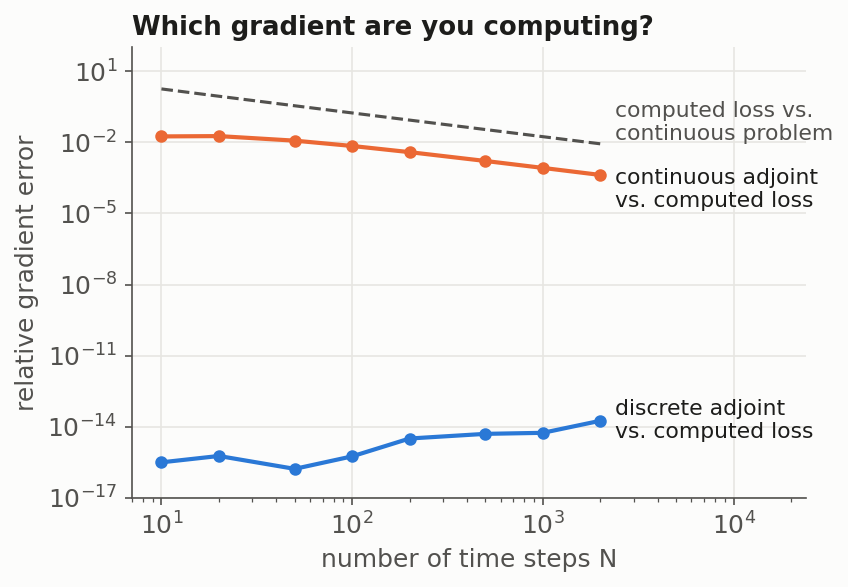

In [7]:
fig, ax = plt.subplots(figsize=(5.8, 3.9))
ax.loglog(Ns, np.maximum(err_disc, 1e-17), color=BLUE, marker="o", ms=5)
ax.loglog(Ns, err_cont, color=ORANGE, marker="o", ms=5)
ax.loglog(Ns, err_euler, color=INK2, ls="--", lw=1.5)
ax.text(Ns[-1] * 1.2, err_disc[-1], "discrete adjoint\nvs. computed loss", color=INK, fontsize=10.5, va="center")
ax.text(Ns[-1] * 1.2, err_cont[-1] / 4, "continuous adjoint\nvs. computed loss", color=INK, fontsize=10.5, va="center")
ax.text(Ns[-1] * 1.2, err_euler[-1] * 8, "computed loss vs.\ncontinuous problem", color=INK2, fontsize=10.5, va="center")
ax.set(xlabel="number of time steps N", ylabel="relative gradient error", xlim=(7, 2000 * 12), ylim=(1e-17, 100),
       title="Which gradient are you computing?")

The blue line shows that the discrete adjoint is exact for the computation we ran, at every step size, up to rounding error, so it's the gradient of exactly the function the optimizer evaluates. The orange line shows that the discretized continuous adjoint is not. Its disagreement with the computed loss shrinks like $h$, but at any finite step size it isn't the exact gradient of either the loss we computed or the continuous one. The dashed gray line shows that neither of them is the gradient of the continuous problem. The forward-Euler simulation is itself only accurate to $O(h)$, so even the exact gradient of the computed loss differs from the continuous problem's gradient by $O(h)$, and here that error is actually *larger* than the orange inconsistency.

The orange inconsistency still matters, though, because an optimizer only ever sees the computed loss. Line searches compare the computed loss with the slope the gradient predicts. If the two disagree, line searches can fail near the optimum, and the point where the inconsistent gradient vanishes isn't a minimizer of the computed loss. A consistent gradient makes convergence checks mean what they say. Gholami et al. (2019) and Onken and Ruthotto (2020) document exactly this effect when training neural ODEs. (Neural ODEs also reconstruct the forward trajectory by solving the state equation backward in time, which adds a further error and can be unstable.)

The two routes agree when the adjoint equation is discretized in exactly the way the discrete adjoint dictates. For forward Euler, that's the blue recursion: it *is* a discretization of the continuous adjoint equation, just with the Jacobian at $s_k$. For Runge–Kutta methods the answer is known precisely. Hager (2000) and Sanz-Serna (2016) showed that the discrete adjoint of a Runge–Kutta method is itself a Runge–Kutta method for the adjoint equation, and that the forward and adjoint methods together form a *symplectic partitioned* Runge–Kutta pair. Numerical schemes designed so that this holds are called **adjoint-consistent** or **structure-preserving**: differentiating and discretizing commute.

## 5. Recap

- A feed-forward network is a loop $a_{k+1} = \Phi_k(a_k, \theta_k)$, exactly the kind of computation the adjoint method was made for. **Backpropagation is the adjoint method applied to that loop.** Its error signal $\delta_k = \partial\mathcal{L}/\partial z_k$ is the adjoint, measured just before the nonlinearity.
- The same few lines of code compute gradients for an optimal-control problem and for a neural network. Each problem only supplies its step and that step's vector–Jacobian product, which is how automatic-differentiation libraries are organized.
- A residual network is forward Euler for an ODE in which depth is time and the weights are a control. Training it is an optimal control problem, and neural ODEs take this literally.
- **Discretize-then-differentiate** gives the exact gradient of the computation you ran. **Differentiate-then-discretize** gives something close to it, but generally different at any finite step size. The two coincide only for adjoint-consistent schemes.

Finally, the adjoint has been discovered independently in several fields, and each one gave it its own name:

| Name | Field |
|---|---|
| adjoint variable | numerical analysis, PDE-constrained optimization, weather forecasting |
| costate | optimal control |
| Lagrange multiplier | constrained optimization |
| error signal $\delta$, "gradient with respect to the activations" | neural networks |
| cotangent, vector–Jacobian product | automatic differentiation |

**References**

- Kelley, H. J. (1960). Gradient theory of optimal flight paths. *ARS Journal*, 30(10).
- Bryson, A. E. and Denham, W. F. (1962). A steepest-ascent method for solving optimum programming problems. *Journal of Applied Mechanics*, 29(2).
- LeCun, Y. (1988). A theoretical framework for back-propagation. *Proceedings of the 1988 Connectionist Models Summer School*.
- Hager, W. W. (2000). Runge–Kutta methods in optimal control and the transformed adjoint system. *Numerische Mathematik*, 87.
- He, K., Zhang, X., Ren, S. and Sun, J. (2016). Deep residual learning for image recognition. *CVPR*.
- Sanz-Serna, J. M. (2016). Symplectic Runge–Kutta schemes for adjoint equations, automatic differentiation, optimal control, and more. *SIAM Review*, 58(1).
- Chen, R. T. Q., Rubanova, Y., Bettencourt, J. and Duvenaud, D. (2018). Neural ordinary differential equations. *NeurIPS*.
- Gholami, A., Keutzer, K. and Biros, G. (2019). ANODE: Unconditionally accurate memory-efficient gradients for neural ODEs. *IJCAI*.
- Onken, D. and Ruthotto, L. (2020). Discretize-optimize vs. optimize-discretize for time-series regression and continuous normalizing flows. arXiv:2005.13420.